# Here we check if the entangling operator can be absorbed into the standard block

Absorbing the entangling block into the brick-wall circuit allows to create the peaked circuit with two peaks (see paper: ArXix...)

Block like this

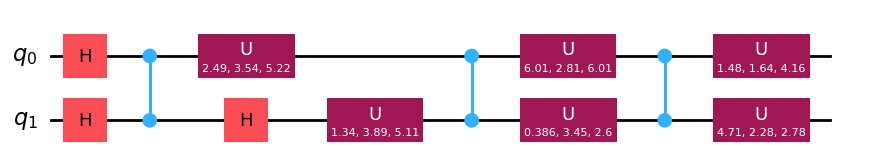

is converted into the block like this

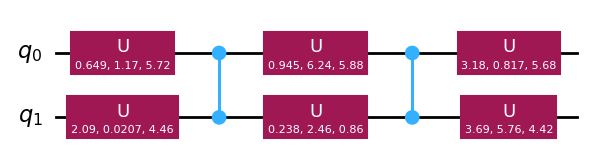

After we demonstarte that the entangled block can be absorbed, we show that a peaked circuit with double peak can be cretaed and the entaglemnt block can be hidden in it.

### Import libraries

In [69]:
import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex
from IPython.display import display
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile

import numpy as np
import random
import copy

# SciPy minimizer routine
from scipy.optimize import minimize

import time

PI = np.pi

### Definig functions that create a single "brick" in the brick wall ciruit modify these "bricks"

In [52]:
#Creates a single "brick" block and add it to an existing circuit
def add_double_cz_block(qc, params, qubits_list):
    qc.u(params[0], params[1], params[2], qubits_list[0])
    qc.u(params[3], params[4], params[5], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[6], params[7], params[8], qubits_list[0])
    qc.u(params[9], params[10], params[11], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[12], params[13], params[14], qubits_list[0])
    qc.u(params[15], params[16], params[17], qubits_list[1])
    return qc
    
#Creates a single inverted "brick" block and add it to an existing circuit
def add_double_cz_block_ent(qc, params, qubits_list):
    qc.h(0)
    qc.h(1)
    qc.cz(0,1)
    qc.h(1)
    qc.u(params[0], params[1], params[2], qubits_list[0])
    qc.u(params[3], params[4], params[5], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[6], params[7], params[8], qubits_list[0])
    qc.u(params[9], params[10], params[11], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[12], params[13], params[14], qubits_list[0])
    qc.u(params[15], params[16], params[17], qubits_list[1])
    return qc
#Creates a single "brick" block operator
def double_cz_op(par):
    q_2 = qiskit.QuantumCircuit(2)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.cz(0,1)
    q_2.u(par[6], par[7], par[8], 0)
    q_2.u(par[9], par[10], par[11], 1)
    q_2.cz(0,1)
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    op = Operator(q_2)
    return op.data

#Creates a single "brick" block operator with entangling block
def double_cz_op_ent(par):
    q_2 = qiskit.QuantumCircuit(2)
    q_2.h(0)
    q_2.h(1)
    q_2.cz(0,1)
    q_2.h(1)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.cz(0,1)
    q_2.u(par[6], par[7], par[8], 0)
    q_2.u(par[9], par[10], par[11], 1)
    q_2.cz(0,1)
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    op = Operator(q_2)
    return op.data

#Calculate difference between two "brick" blocks
def double_q_diff(mat_1, mat_2):
    mm = mat_1 - mat_2
    return np.linalg.norm(mm)
# auxialiry function for optimization
def estim_func_ent(params, params_init):
    init_circ = double_cz_op_ent(params_init)
    test_circ = double_cz_op(params)
    est = double_q_diff(init_circ, test_circ)
    return est

#Take an intial "brick" block with entanglement block and find a "brick" block (without entanglement) that performs alsmost the same function
    find = 0
    for i_try in range(100):
        param_0 = []
        for i in range(18):
            param_0.append(random.random() * 2 * PI)
      
        res = minimize(
                    estim_func_ent,
                    param_0,
                    args = (param_init),
                    method = 'SLSQP', 
                    options = {"maxiter":  5000} 
                )
        if res.fun < 0.1:
            break
    
    return res

In [53]:
# Define parameter for the "brick" block
param_init = []
for j in range(18):
    param_init.append(random.random() * 2 * PI)

In [54]:
#Take an intial "brick" block with entanglement (and parameter defined above) and find a "brick" block (without entanglement) that performs alsmost the same function
import time
start_time = time.time()
new_params = []
block_devs = []
for i in range(3): # seral tries are performed
    res_min = find_alt_params_ent_abs(param_init)
    new_params.append(res_min.x)
    block_devs.append(res_min.fun)
  
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")

Elapsed time: 15.811280012130737 seconds


In [55]:
#Deviations (for each try in the previos section) of the new block from the inital block
block_devs

[0.051113666209942746, 0.05092386800234445, 0.03770198399133871]

In [59]:
#show matrices corresponding to inital block with entaglement and final block
qc_init = qiskit.QuantumCircuit(2)
qc_init = add_double_cz_block_ent(qc_init, param_init, [0,1])
op = Operator(qc_init)
display(array_to_latex(op, precision=3))
qc_init.measure_all()

qc_red = qiskit.QuantumCircuit(2)
qc_red = add_double_cz_block(qc_red, new_params[0], [0,1])
op = Operator(qc_red)
display(array_to_latex(op, precision=3))
qc_red.measure_all()

#Simulate both initial and final blocks
simulator = AerSimulator()
qc_init_t = transpile(qc_init, simulator)
result = simulator.run(qc_init_t,shots = 10000).result()
counts_init = result.get_counts(qc_init_t)

simulator = AerSimulator()
qc_red_t = transpile(qc_red, simulator)
result = simulator.run(qc_red_t,shots = 10000).result()
counts_red = result.get_counts(qc_red_t)


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [60]:
#Show counts for inital block
counts_init

{'11': 3532, '00': 3067, '10': 868, '01': 2533}

In [61]:
#Show counts for final block
counts_red

{'11': 3537, '00': 3115, '01': 2481, '10': 867}

### Creating a double peaked circuit

In [62]:
# the function find a modified  inverse "brick" for hiding the peaked circuit (see paper: ArXiv...)
def find_alt_params_inv_bloc(param_init):
    find = 0
    for i_try in range(100):
        param_0 = []
        for i in range(18):
            param_0.append(random.random() * 2 * PI)
    
       
        res = minimize(
                    estim_func_inv_block,
                    param_0,
                    args = (param_init),
                    method = 'SLSQP', 
                    options = {"maxiter":  5000} 
                )
        #if res.success == 'True':
        if res.fun < 0.1:
            break
    print(i_try)
    return res

# creating the entanglement block
def add_double_cz_block_ent_bar(qc, params, qubits_list):
    qc.h(0)
    qc.h(1)
    qc.cz(0,1)
    qc.h(1)
    qc.barrier()
    qc.u(params[0], params[1], params[2], qubits_list[0])
    qc.u(params[3], params[4], params[5], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[6], params[7], params[8], qubits_list[0])
    qc.u(params[9], params[10], params[11], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[12], params[13], params[14], qubits_list[0])
    qc.u(params[15], params[16], params[17], qubits_list[1])
    return qc
# creating an inversed "brick"
def add_double_inverse_cz_block(qc, params, qubits_list):
    pp = params
    qc.u(-pp[12], -pp[14], -pp[13], qubits_list[0])
    qc.u(-pp[15], -pp[17], -pp[16], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(-pp[6], -pp[8], -pp[7], qubits_list[0])
    qc.u(-pp[9], -pp[11], -pp[10], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(-pp[0], -pp[2], -pp[1], qubits_list[0])
    qc.u(-pp[3], -pp[5], -pp[4], qubits_list[1])
    return qc

#auxiliary function used in optimization
def estim_func_inv_block(params, params_init):
    init_circ = double_cz_op(params_init)
    test_circ = double_cz_op(params)
    est = double_q_diff(init_circ, test_circ)
   
    return est

In [63]:
#the circuit consist of 2 bricks only
#here the first brick parameters are defined
param_init = []
for j in range(18):
    param_init.append(random.random() * 2 * PI)

0


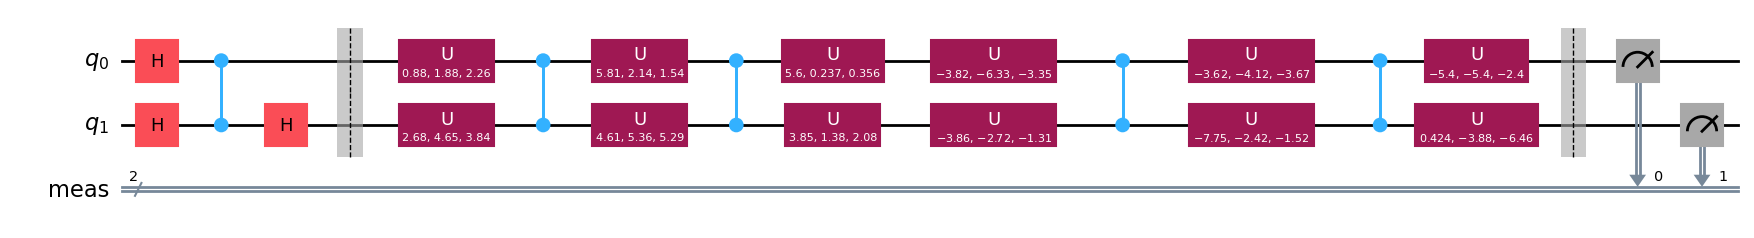

In [66]:
#create a circut with entanglement block + a single peaked circuit
#Enatglment block is spilt by a barrier
#the rest is the peaked circuit with |00> peaked string
#Finally, the whole circuit should give double peaks at |00> and |11>
qc = qiskit.QuantumCircuit(2)
qc = add_double_cz_block_ent_bar(qc, param_init, [0,1])
new_params_mir = []
res_min = find_alt_params_inv_bloc(param_init)
new_params_mir.append(res_min.x)
#qc = add_double_cz_block(qc, new_params[0], [0,1])
qc = add_double_inverse_cz_block(qc, new_params_mir[0], [0,1])
qc.measure_all()
qc.draw('mpl')

In [67]:
#simulating the double peaked circuit
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
simulator = AerSimulator()
qc_init_t = transpile(qc, simulator)
result = simulator.run(qc_init_t,shots = 10000).result()
counts_init = result.get_counts(qc_init_t)


In [68]:
#Show counts
counts_init

{'00': 5100, '11': 4900}

In [70]:
# hiding the entanglement block into the first brick of the brick-wall circuit.
start_time = time.time()
new_params_ent = []
block_devs = []
for i in range(3):
    res_min = find_alt_params_ent_abs(param_init)
    new_params_ent.append(res_min.x)
    block_devs.append(res_min.fun)
    
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")

Elapsed time: 413.21746253967285 seconds


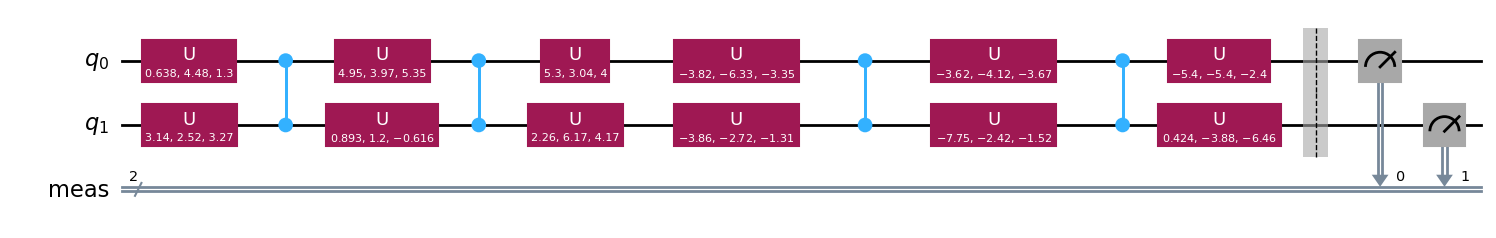

In [74]:
#creating a new circuit with absorbed enatangling block
qc_mer = qiskit.QuantumCircuit(2)
qc_mer = add_double_cz_block(qc_mer, new_params_ent[0], [0,1])
qc_mer = add_double_inverse_cz_block(qc_mer, new_params_mir[0], [0,1])
qc_mer.measure_all()
qc_mer.draw('mpl')

In [75]:
#Simulate the double peaked random ciruit
simulator = AerSimulator()
qc_mer_t = transpile(qc_mer, simulator)
result = simulator.run(qc_mer_t,shots = 10000).result()
counts_mer = result.get_counts(qc_mer_t)

In [76]:
# Show counts
# One can see that there are two main peaks and some small probability on some other strings
counts_mer

{'01': 134, '00': 4557, '11': 5007, '10': 302}

### Creating a figure demonstrating the idea of making double peaked circuit

In [79]:
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Draw the circuit using the matplotlib backend
fig = circuit_drawer(qc, output='mpl')

# Add a text annotation to the figure
#fig.text(0.5, 0.90, "(a)", ha='center', fontsize=14)

# Save or show
fig.savefig("fig_double_peak_a.eps", format='eps', dpi=300, bbox_inches='tight')
plt.show()

# Draw the circuit using the matplotlib backend
fig_mer = circuit_drawer(qc_mer, output='mpl')

# Add a text annotation to the figure
#fig_mer.text(0.5, 0.90, "(b)", ha='center', fontsize=14)

# Save or show
fig_mer.savefig("fig_double_peak_b.eps", format='eps', dpi=300, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
